# Verification: Cooperative Bivalent Binding (Posner et al., 2004)

This notebook verifies the NFsim BNGL model against the analytical equilibrium
theory of Wofsy and Goldstein (1987). The model describes bivalent ligand (23G3
antibody) binding cooperatively to bivalent cell-surface receptor (IgE–FcεRI).

**Verification approach:**
- Solve the Wofsy–Goldstein equilibrium equations (eqs 10, 15, 17) algebraically
  using `scipy.optimize` for each ligand concentration.
- Run the BNGL NFsim parameter scan to obtain stochastic equilibrium binding fractions.
- Compare the theoretical fraction of epitopes bound ($q$) with the NFsim result.
- Overlay both on a reproduction of Fig. 3a in Posner et al. (2004).

**Models verified:**
- `cooperative_bivalent_binding_posner2004.bngl` (primary, no rings)
- `cooperative_bivalent_binding_posner2004_rings.bngl` (variant, +rings params)

In [1]:
import subprocess
import os
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.')
print('Working directory:', os.getcwd())

Working directory: /Users/wish/Code/BNGL_library/models/cooperative_bivalent_binding_posner2004


## Wofsy–Goldstein Equilibrium Theory (no rings)

From Wofsy & Goldstein (1987), Mol Immunol 24:151–161.

**Dimensionless quantities** (eqs 4a–7):
- $c = 2KC$ (free ligand, $C$ in nM, $K$ in /nM)
- $k = 2K_x X_T$ (cross-linking; equals $K_x S_T$ since $S_T = 2X_T$)
- $\sigma = H$ (cooperativity)
- $\delta = ck\sigma / (1 + 2c + c^2\sigma)$
- $\eta = (1 + c\sigma)^2 / [\sigma(1 + 2c + c^2\sigma)]$

**IgE conservation** (eq 10, $J_n = 0$):
$$1 = w(1-\eta) + \frac{\eta w}{(1-\delta w)^2}$$

**Fraction of epitopes bound** (eq 17, $c_m = 0$):
$$q = 1 - \frac{w(1+c)}{1+2c+c^2\sigma} - \frac{\eta\delta w^2}{(1+c\sigma)(1-\delta w)}$$

**Ligands bound per IgE** (eq 15, $c_m = 0$):
$$c_b = 1 + \frac{w}{1-\delta w}\left[\frac{2c(1+c\sigma)}{1+2c+c^2\sigma} - 1\right]
      + \frac{(1-\eta)\delta w^2}{1-\delta w}$$

**Ligand conservation:**
$$A_T = C_{\text{free}} + C_{RT} \cdot c_b$$
where $C_{RT} = C \cdot R_T$ in nM (= $C_{ST}/2$).

In [2]:
def solve_wofsy_equilibrium(AT_nM, K, k, sigma, CRT):
    """
    Solve Wofsy-Goldstein equilibrium (no rings, no monovalent ligand).
    
    Parameters
    ----------
    AT_nM : float
        Total antibody concentration (nM).
    K : float
        Single-site binding constant (/nM).
    k : float
        Dimensionless cross-linking parameter (= KxST).
    sigma : float
        Cooperativity parameter (= H).
    CRT : float
        C * RT in nM (receptor concentration in bulk).
    
    Returns
    -------
    C_free : float  — free ligand concentration (nM)
    w : float       — fraction of unaggregated IgE
    q : float       — fraction of epitopes bound
    c_b : float     — ligands bound per IgE
    """
    if AT_nM < 1e-15:
        return 0.0, 1.0, 0.0, 0.0
    
    def _derived(c):
        """Compute delta, eta from dimensionless free ligand c."""
        D = 1 + 2*c + c**2 * sigma
        delta = c * k * sigma / D if D > 0 else 0.0
        eta = (1 + c*sigma)**2 / (sigma * D) if D > 0 else 1.0/sigma
        return delta, eta
    
    def _solve_w(c):
        """Solve eq 10 for w given c (J_n = 0)."""
        delta, eta = _derived(c)
        if delta < 1e-15:
            # delta -> 0: eq 10 becomes 1 = w, so w = 1
            return 1.0
        def eq10(w):
            dw = delta * w
            if dw >= 1:
                return -1e10
            return w*(1 - eta) + eta*w/(1 - dw)**2 - 1
        w_max = min(1.0, (1 - 1e-8)/delta)
        try:
            return brentq(eq10, 1e-15, w_max, xtol=1e-14)
        except ValueError:
            return 1.0
    
    def _compute_q(c, w):
        """Fraction of epitopes bound (eq 17, c_m = 0)."""
        delta, eta = _derived(c)
        D = 1 + 2*c + c**2*sigma
        dw = delta * w
        term1 = w * (1 + c) / D
        term2 = eta * delta * w**2 / ((1 + c*sigma) * (1 - dw)) if (1 - dw) > 1e-15 else 0.0
        return 1 - term1 - term2
    
    def _compute_cb(c, w):
        """Ligands bound per IgE (eq 15, c_m = 0)."""
        delta, eta = _derived(c)
        D = 1 + 2*c + c**2*sigma
        dw = delta * w
        if abs(1 - dw) < 1e-15:
            return 0.0
        bracket = 2*c*(1 + c*sigma)/D - 1
        return 1 + w/(1 - dw) * bracket + (1 - eta)*delta*w**2/(1 - dw)
    
    def _AT_from_Cfree(C_free):
        """Compute total Ab from free Ab via ligand conservation."""
        c = 2 * K * C_free
        w = _solve_w(c)
        cb = _compute_cb(c, w)
        return C_free + CRT * cb
    
    # Find C_free in [0, AT] such that _AT_from_Cfree(C_free) = AT_nM
    f = lambda Cf: _AT_from_Cfree(Cf) - AT_nM
    try:
        C_free = brentq(f, 0, AT_nM, xtol=1e-14)
    except ValueError:
        C_free = AT_nM
    
    c = 2 * K * C_free
    w = _solve_w(c)
    q = _compute_q(c, w)
    cb = _compute_cb(c, w)
    return C_free, w, q, cb

print('Solver defined.')

Solver defined.


## Compute theoretical binding curves

In [3]:
# Parameters from Table 1, Posner et al. (2004)
params_norings = dict(K=0.098, k=2.5, sigma=0.39)   # -rings
params_rings   = dict(K=0.097, k=1.9, sigma=0.39)   # +rings

# Shared experimental parameters
CST = 1.0    # nM (C * S_T)
CRT = CST/2  # nM (C * R_T)

# Dense scan for smooth theory curves
AT_theory = np.logspace(np.log10(0.01), np.log10(1000), 200)

results = {}
for label, p in [('no rings', params_norings), ('with rings', params_rings)]:
    q_arr = np.zeros_like(AT_theory)
    w_arr = np.zeros_like(AT_theory)
    for i, AT in enumerate(AT_theory):
        C_free, w, q, cb = solve_wofsy_equilibrium(AT, p['K'], p['k'], p['sigma'], CRT)
        q_arr[i] = q
        w_arr[i] = w
    results[label] = dict(AT=AT_theory, q=q_arr, w=w_arr)
    print(f'{label}: q ranges from {q_arr[0]:.4f} to {q_arr[-1]:.4f}')

no rings: q ranges from 0.0047 to 0.9873
with rings: q ranges from 0.0040 to 0.9872


## Run BNGL NFsim parameter scans

In [4]:
models = {
    'no rings': {
        'bngl': 'cooperative_bivalent_binding_posner2004.bngl',
        'scan': 'cooperative_bivalent_binding_posner2004_scan.scan',
    },
    'with rings': {
        'bngl': 'cooperative_bivalent_binding_posner2004_rings.bngl',
        'scan': 'cooperative_bivalent_binding_posner2004_rings_scan.scan',
    },
}

# RT scaled by f
f = 0.003
RT_sim = 3e5 * f  # = 900

for label, m in models.items():
    print(f'\nRunning {label}: {m["bngl"]}')
    result = subprocess.run(
        ['bionetgen', 'run', '-i', m['bngl']],
        capture_output=True, text=True, timeout=600
    )
    if result.returncode != 0:
        print(f'  ERROR: {result.stderr[-500:]}')
    else:
        print(f'  Completed successfully.')
    
    # Load scan output
    scan_file = m['scan']
    if os.path.exists(scan_file):
        data = np.loadtxt(scan_file, comments='#')
        AT_scan = data[:, 0]          # AT_nM values
        # Column 1 is Obs_L_tot; R_l1 and R_l2 are columns 2,3
        R_l1 = data[:, 2]             # Obs_R_l1_bound
        R_l2 = data[:, 3]             # Obs_R_l2_bound
        frac_bound = (R_l1 + R_l2) / (2 * RT_sim)
        m['AT_scan'] = AT_scan
        m['frac_bound'] = frac_bound
        print(f'  Loaded {len(AT_scan)} scan points from {scan_file}')
    else:
        print(f'  WARNING: {scan_file} not found')


Running no rings: cooperative_bivalent_binding_posner2004.bngl


  Completed successfully.
  Loaded 20 scan points from cooperative_bivalent_binding_posner2004_scan.scan

Running with rings: cooperative_bivalent_binding_posner2004_rings.bngl


  Completed successfully.
  Loaded 20 scan points from cooperative_bivalent_binding_posner2004_rings_scan.scan


## Comparison: Theory vs NFsim

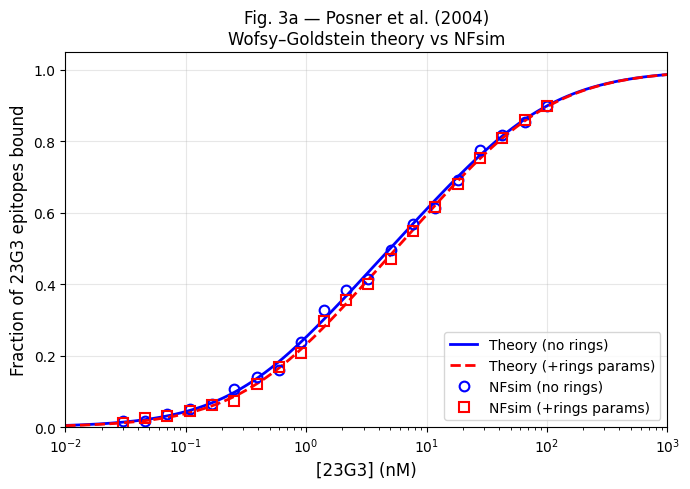

Saved verify_posner2004.png


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Theory curves
ax.plot(results['no rings']['AT'], results['no rings']['q'],
        'b-', lw=2, label='Theory (no rings)')
ax.plot(results['with rings']['AT'], results['with rings']['q'],
        'r--', lw=2, label='Theory (+rings params)')

# NFsim data
if 'AT_scan' in models['no rings']:
    ax.plot(models['no rings']['AT_scan'], models['no rings']['frac_bound'],
            'bo', ms=7, mfc='none', mew=1.5, label='NFsim (no rings)')
if 'AT_scan' in models['with rings']:
    ax.plot(models['with rings']['AT_scan'], models['with rings']['frac_bound'],
            'rs', ms=7, mfc='none', mew=1.5, label='NFsim (+rings params)')

ax.set_xscale('log')
ax.set_xlabel('[23G3] (nM)', fontsize=12)
ax.set_ylabel('Fraction of 23G3 epitopes bound', fontsize=12)
ax.set_xlim(0.01, 1000)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower right')
ax.set_title('Fig. 3a — Posner et al. (2004)\nWofsy–Goldstein theory vs NFsim', fontsize=12)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('verify_posner2004.png', dpi=150)
plt.show()
print('Saved verify_posner2004.png')

## Error analysis

In [6]:
print(f'{"Model":<20s} {"Max |error|":<15s} {"Mean |error|":<15s} {"N points":<10s}')
print('-' * 60)

for label in ['no rings', 'with rings']:
    m = models[label]
    p = params_norings if label == 'no rings' else params_rings
    if 'AT_scan' not in m:
        print(f'{label:<20s} NO DATA')
        continue
    
    # Compute theory at the same AT values as the scan
    q_theory = np.zeros(len(m['AT_scan']))
    for i, AT in enumerate(m['AT_scan']):
        _, _, q, _ = solve_wofsy_equilibrium(AT, p['K'], p['k'], p['sigma'], CRT)
        q_theory[i] = q
    
    errors = np.abs(m['frac_bound'] - q_theory)
    max_err = np.max(errors)
    mean_err = np.mean(errors)
    n = len(errors)
    print(f'{label:<20s} {max_err:<15.4f} {mean_err:<15.4f} {n:<10d}')
    
    # Store for reference
    m['q_theory'] = q_theory
    m['errors'] = errors

print()
print('Note: NFsim errors reflect stochastic noise at finite molecule counts')
print(f'(RT = {RT_sim:.0f} receptors per simulation). Errors < 0.05 indicate')
print('good agreement between the stochastic and deterministic solutions.')

Model                Max |error|     Mean |error|    N points  
------------------------------------------------------------
no rings             0.0260          0.0090          20        
with rings           0.0186          0.0061          20        

Note: NFsim errors reflect stochastic noise at finite molecule counts
(RT = 900 receptors per simulation). Errors < 0.05 indicate
good agreement between the stochastic and deterministic solutions.
